<a href="https://colab.research.google.com/github/100abhishek/Credit-Card-Fraud-Detection/blob/main/Real_Time_Credit_Card_Fraud_Detection_Using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install imbalanced-learn

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Handling imbalance
from imblearn.over_sampling import SMOTE


In [3]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Check data types and missing values
print("\nDataset info:")
df.info()

# Check for nulls
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (284807, 31)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20  

In [6]:
# Value counts
print("\nTransaction Class Distribution:")
print(df['Class'].value_counts())

# Percentage of frauds
fraud_percent = (df['Class'].value_counts()[1] / df.shape[0]) * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percent:.4f}%")



Transaction Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of fraudulent transactions: 0.1727%


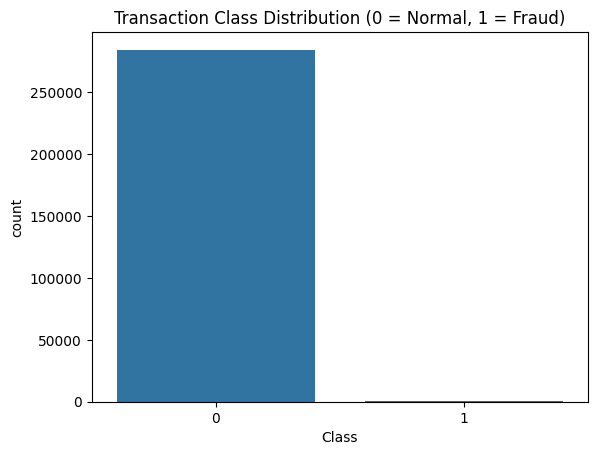

In [7]:
sns.countplot(data=df, x='Class')
plt.title("Transaction Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()


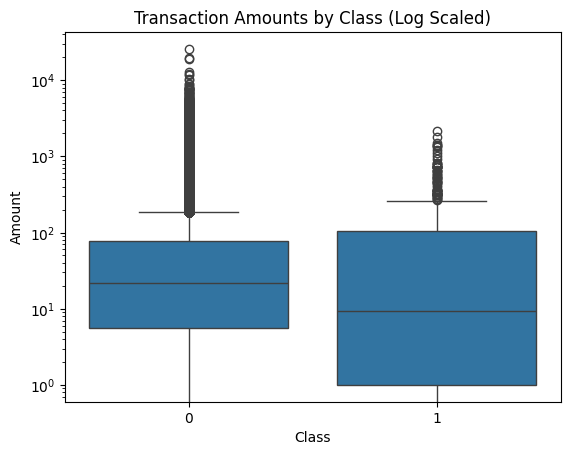

In [8]:
# Boxplot of amount by class
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')  # Fraud amounts vary a lot
plt.title("Transaction Amounts by Class (Log Scaled)")
plt.show()


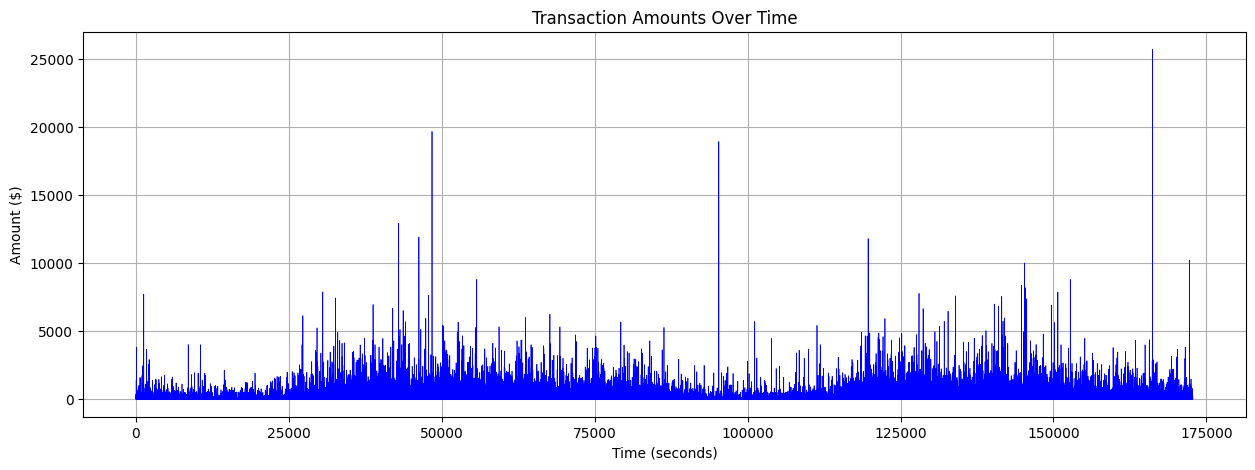

In [9]:
plt.figure(figsize=(15,5))
plt.plot(df['Time'], df['Amount'], color='blue', linewidth=0.5)
plt.title('Transaction Amounts Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.show()


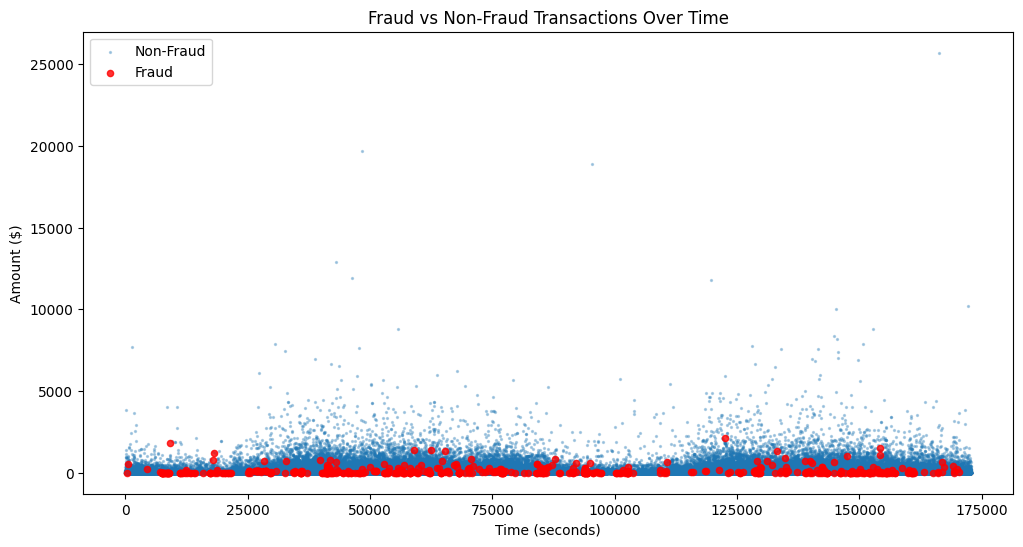

In [10]:
plt.figure(figsize=(12,6))

# Non-fraud transactions
non_fraud = df[df['Class'] == 0]
plt.scatter(non_fraud['Time'], non_fraud['Amount'], label='Non-Fraud', alpha=0.3, s=2)

# Fraud transactions
fraud = df[df['Class'] == 1]
plt.scatter(fraud['Time'], fraud['Amount'], label='Fraud', alpha=0.8, s=20, color='red')

plt.title('Fraud vs Non-Fraud Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount ($)')
plt.legend()
plt.show()


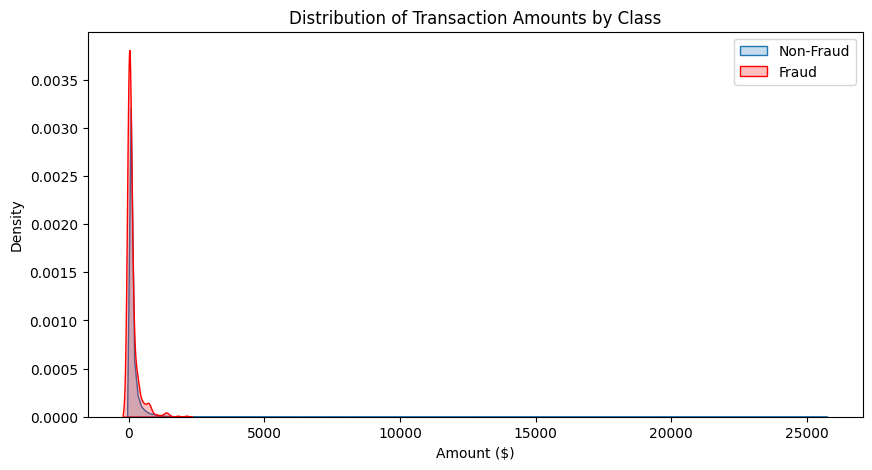

In [11]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Non-Fraud', fill=True)
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud', fill=True, color='red')
plt.title('Distribution of Transaction Amounts by Class')
plt.xlabel('Amount ($)')
plt.legend()
plt.show()


In [12]:
X = df.drop(['Class'], axis=1)
y = df['Class']


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of training data:", X_train.shape)
print("Shape of test data:", X_test.shape)


Shape of training data: (199364, 30)
Shape of test data: (85443, 30)


In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Class
0    199020
1       344
Name: count, dtype: int64
After SMOTE: Class
0    199020
1    199020
Name: count, dtype: int64


In [16]:
#logistic-regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train the model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Predict on test data
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Logistic Regression Results:\n")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=4))


Logistic Regression Results:

[[83376  1919]
 [   18   130]]
              precision    recall  f1-score   support

           0     0.9998    0.9775    0.9885     85295
           1     0.0634    0.8784    0.1183       148

    accuracy                         0.9773     85443
   macro avg     0.5316    0.9279    0.5534     85443
weighted avg     0.9982    0.9773    0.9870     85443



In [17]:
#random forest
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Results:\n")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))


Random Forest Results:

[[85277    18]
 [   31   117]]
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     85295
           1     0.8667    0.7905    0.8269       148

    accuracy                         0.9994     85443
   macro avg     0.9332    0.8952    0.9133     85443
weighted avg     0.9994    0.9994    0.9994     85443



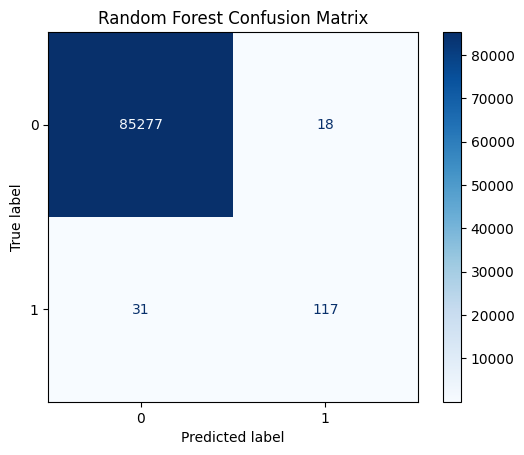

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()


In [19]:
#use xgboost for better accuracy
!pip install xgboost
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix


In [20]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:18:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [21]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Results:\n")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))


XGBoost Results:

[[84936   359]
 [   24   124]]
              precision    recall  f1-score   support

           0     0.9997    0.9958    0.9978     85295
           1     0.2567    0.8378    0.3930       148

    accuracy                         0.9955     85443
   macro avg     0.6282    0.9168    0.6954     85443
weighted avg     0.9984    0.9955    0.9967     85443



In [22]:
from sklearn.metrics import classification_report
import joblib

# Get classification reports as dictionaries
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# Extract F1-scores for class '1' (fraud)
f1_lr = report_lr['1']['f1-score']
f1_rf = report_rf['1']['f1-score']
f1_xgb = report_xgb['1']['f1-score']

# Print comparison
print("\nModel F1-Scores for Class 1 (Fraud):")
print(f"Logistic Regression: {f1_lr:.4f}")
print(f"Random Forest:       {f1_rf:.4f}")
print(f"XGBoost:             {f1_xgb:.4f}")

# Determine the best model
f1_scores = {
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf,
    'XGBoost': f1_xgb
}

best_model_name = max(f1_scores, key=f1_scores.get)
print(f"\n✅ Best model based on F1-score (class 1): {best_model_name}")

# Save the best model
if best_model_name == 'Logistic Regression':
    joblib.dump(lr, 'best_model.pkl')
elif best_model_name == 'Random Forest':
    joblib.dump(rf, 'best_model.pkl')
else:
    joblib.dump(xgb_model, 'best_model.pkl')

print("✅ Best model saved as 'best_model.pkl'")



Model F1-Scores for Class 1 (Fraud):
Logistic Regression: 0.1183
Random Forest:       0.8269
XGBoost:             0.3930

✅ Best model based on F1-score (class 1): Random Forest
✅ Best model saved as 'best_model.pkl'


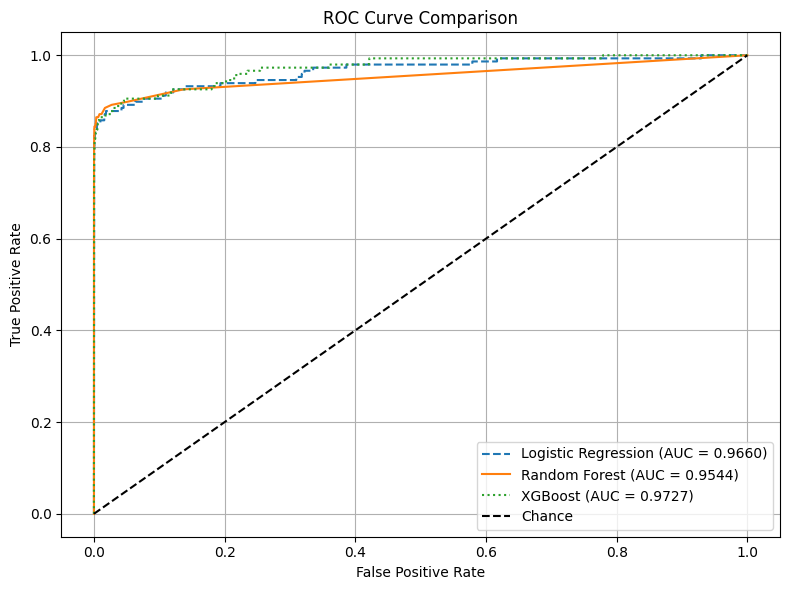

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores (only for class 1)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot all ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linestyle='--')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linestyle='-')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linestyle=':')

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


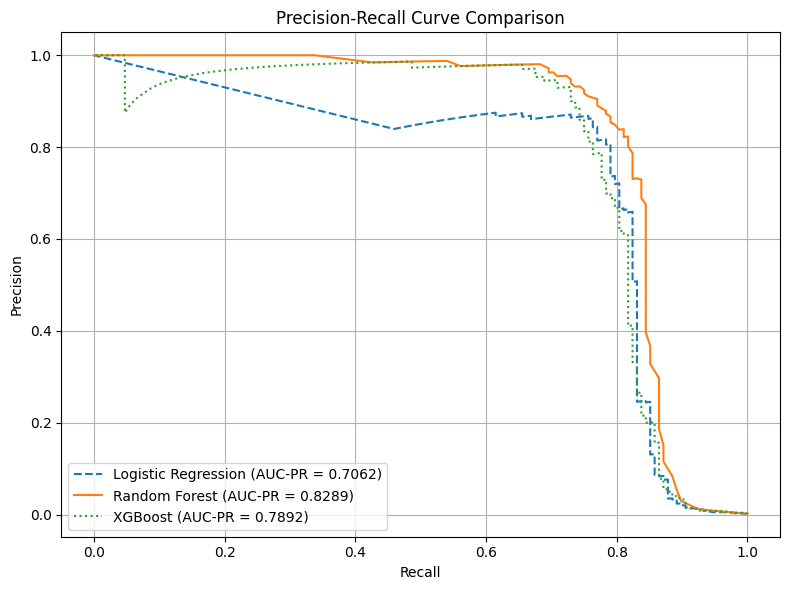

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probability scores (only for class 1)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve and AUC-PR for each model
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

auc_pr_lr = average_precision_score(y_test, y_proba_lr)
auc_pr_rf = average_precision_score(y_test, y_proba_rf)
auc_pr_xgb = average_precision_score(y_test, y_proba_xgb)

# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))

plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC-PR = {auc_pr_lr:.4f})', linestyle='--')
plt.plot(recall_rf, precision_rf, label=f'Random Forest (AUC-PR = {auc_pr_rf:.4f})', linestyle='-')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUC-PR = {auc_pr_xgb:.4f})', linestyle=':')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
auc_pr_lr = average_precision_score(y_test, y_proba_lr)
auc_pr_rf = average_precision_score(y_test, y_proba_rf)
auc_pr_xgb = average_precision_score(y_test, y_proba_xgb)


In [26]:
print(f"Logistic Regression AUC-PR: {auc_pr_lr:.4f}")
print(f"Random Forest AUC-PR: {auc_pr_rf:.4f}")
print(f"XGBoost AUC-PR: {auc_pr_xgb:.4f}")

Logistic Regression AUC-PR: 0.7062
Random Forest AUC-PR: 0.8289
XGBoost AUC-PR: 0.7892


In [27]:
plt.tight_layout()
plt.show()  # This ensures that the plot is displayed in your notebook.


<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 8))  # Try increasing the figure size for better visibility


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [28]:
print("y_test shape:", y_test.shape)
print("y_proba_lr shape:", y_proba_lr.shape)
print("y_proba_rf shape:", y_proba_rf.shape)
print("y_proba_xgb shape:", y_proba_xgb.shape)


y_test shape: (85443,)
y_proba_lr shape: (85443,)
y_proba_rf shape: (85443,)
y_proba_xgb shape: (85443,)


In [ ]:
import gradio as gr
import joblib
import numpy as np

# Load your saved model
model = joblib.load("best_model.pkl")

# Predict function
def predict_fraud(V4, V11, V14, V17, Amount):
    input_data = np.array([[V4, V11, V14, V17, Amount]])
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = f"🚨 <span style='color:red;font-size:20px;font-weight:bold;'>FRAUD</span><br><span>Confidence: {prob:.2%}</span>"
    else:
        result = f"✅ <span style='color:green;font-size:20px;font-weight:bold;'>NOT FRAUD</span><br><span>Confidence: {prob:.2%}</span>"
    return result

# Build UI with Blocks
with gr.Blocks(css=".gr-button-primary {background-color: #007BFF !important; color: white;}") as demo:
    gr.Markdown("## 💳 Credit Card Fraud Detector")
    gr.Markdown("Enter transaction details below to check if it's **fraudulent** or not. Powered by Random Forest.")

    with gr.Row():
        with gr.Column():
            V4 = gr.Number(label="V4 (Transaction Behavior 1)", value=-1.5)
            V11 = gr.Number(label="V11 (Transaction Behavior 2)", value=2.0)
            V14 = gr.Number(label="V14 (Anomaly Signal)", value=-2.5)
            V17 = gr.Number(label="V17 (Velocity)", value=0.4)
            Amount = gr.Slider(0, 5000, value=120, label="Amount (₹)")
            submit_btn = gr.Button("🚀 Submit", elem_classes=["gr-button-primary"])
        with gr.Column():
            output = gr.HTML(label="Prediction")

    submit_btn.click(
        fn=predict_fraud,
        inputs=[V4, V11, V14, V17, Amount],
        outputs=output
    )

demo.launch(
    inline=True,
    debug=True,
    inbrowser=False,
    share=False
)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>